# Custom State
Node(Agent)간에 공유되는 상태정보를 커스터마이징할수 있다.

**최신 장소정보 공유**
- tool 장소검색api: naver/kakao/google map api(키워드 검색기반)
- tool 자연어 -> 검색을 위한 키워드추출
    - 나 여기 독산동인데, 여기 괜찮은 까페 추천해줘 -> 독산동 까페

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
KAKAO_API_KEY = os.getenv('KAKAO_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

## 카카오 장소검색 도구

https://developers.kakao.com/docs/latest/ko/local/dev-guide#search-by-keyword

In [ ]:
from langchain.tools import tool    # Tool 데코레이터
import requests                     # http(rest-api) 요청 처리
from pprint import pprint
from typing import List, TypedDict  # 타입 힌트

class KakaoPlace(TypedDict):
    name: str
    address: str
    url: str

# 키워드를 이용해 카카오 장소 검색을 수행하는 툴
@tool
def kakao_place_search(query: str) -> List[KakaoPlace]:
    """
    카카오 장소검색 API를 호출하기 위한 도구

    Args:
        query: 검색어(키워드 기반)
    Returns:
        검색 결과
    """
    url = 'https://dapi.kakao.com/v2/local/search/keyword.json'
    headers = {
        'Authorization': f'KakaoAK {KAKAO_API_KEY}'
    }
    params = {'query': query, 'size': 5}  # 최대 5개 검색
    response = requests.get(url, headers=headers, params=params)  # API 호출
    data = response.json()    # JSON -> Python dict
    data = data['documents']  # 장소 목록

    return [
        {
            'name': place['place_name'],
            'address': place['address_name'],
            'url': place['place_url']
        } for place in data
    ]

pprint(kakao_place_search.invoke({'query': '독산동 맛집'}))

[{'address': '서울 금천구 독산동 163-2',
  'name': '왕래성',
  'url': 'http://place.map.kakao.com/538642507'},
 {'address': '서울 금천구 독산동 179-8',
  'name': '청정회센터',
  'url': 'http://place.map.kakao.com/9965001'},
 {'address': '서울 금천구 독산동 288-9',
  'name': '불맛전문관사부간짬뽕 독산직영점',
  'url': 'http://place.map.kakao.com/962610671'},
 {'address': '서울 금천구 독산동 1113',
  'name': '소하떡집',
  'url': 'http://place.map.kakao.com/1448413740'},
 {'address': '서울 금천구 독산동 378-428',
  'name': '돈유창',
  'url': 'http://place.map.kakao.com/1002142708'}]


## 키워드 추출 도구

In [7]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate

llm = init_chat_model('gpt-5.4-mini')

@tool
def extract_keyword(user_request: str) -> str:
    """
    사용자 요청에서 장소검색API를 사용하기 위한 짧고 명확한 키워드를 추출하는 도구
    장소검색도구(kakao_place_search)를 사용하기 전에 사용자의 요청을 먼저 변환하세요.
    """
    
    prompt = PromptTemplate.from_template('''
당신은 사용자의 요청을 장소검색에 필요한 키워드로 변환하는 전문가입니다.
장문의 사용자 요청에서 키워드를 한 문장으로 추출해주세요.
- 키워드는 띄워쓰기로 구분된 한 문장이어야 합니다.
- 다른 설명은 하지말고, 키워드만 추출합니다.

[사용자요청]
{user_request}


[예시]
- 여기 독산동인데, 소문난 맛집좀 알려줘봐 -> 독산동 맛집
- 부산 핫플 좀 알려줘봐 -> 부산 맛집

[금지어]
- 소문난
- 핫플
''')

    chain = prompt | llm
    response = chain.invoke({'user_request': user_request})
    return response.content.strip().strip('"').strip("'")

print(extract_keyword.invoke('여기 독산역 근처인데, 소문난 맛집좀 알려줘!'))
print(extract_keyword.invoke('이따 명동에서 한잔할거야. 맛집 리스트 뽑아줘.'))
print(extract_keyword.invoke('부산에서 가장 핫한 동네가 어디야?'))
print(extract_keyword.invoke('강남에서 가장 유명한 디저트는 뭐야?'))
print(extract_keyword.invoke('인천에서 가장 사람들이 많이 가는 랜드마크는?'))
print(extract_keyword.invoke('경기도 주변 단풍축제 갈만한 곳은?'))

독산역 맛집
명동 맛집
부산 핫한 동네
강남 디저트
인천 랜드마크
경기도 단풍축제


## 그래프 구성
- 키워드 추출 -> 카카오 장소 검색 -> 상태(State)에 결과를 저장하는 LangGraph

In [ ]:
from langgraph.graph import StateGraph, START, END           # 그래프 구성 요소
from langgraph.prebuilt import ToolNode, tools_condition     # 도구 노드, 분기 조건
from typing import Annotated, Optional     # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼
from langchain_core.messages import BaseMessage, ToolMessage  # 메시지 타입

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]  # messages 필드 리스트를 add_messages 규칙으로 누적 저장
    search_query: Optional[str]  # 검색 키워드
    search_results: Optional[List[KakaoPlace]]  # 장소 검색 결과

llm = init_chat_model('gpt-5.4-mini')
tools = [kakao_place_search, extract_keyword]
llm_with_tools = llm.bind_tools(tools)  # llm에 도구 스펙 파인딩

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    if isinstance(state['messages'][-1], ToolMessage):  # 직전에 도구 실행을 한 경우
        if state['messages'][-1].name == 'extract_keyword':  # 키워드 추출 도구면
            state['search_query'] = state['messages'][-1].content  # 검색 키워드 저장
        elif state['messages'][-1].name == 'kakao_place_search':  # 장소 검색 추출 도구면
            state['search_results'] = state['messages'][-1].content  # 검색 결과 저장

    response = llm_with_tools.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {**state, 'messages': [response]}  # state 상태 유지 + 새 응답 메시지 누적 반환

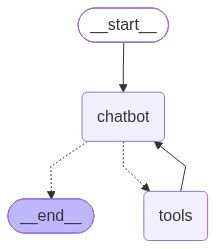

In [10]:
builder = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

builder.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드

builder.add_node('chatbot', chatbot)  # chatbot 노드
builder.add_node('tools', tool_node)  # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile()  # 그래프 컴파일

graph  # 그래프 객체

## 그래프 실행

In [ ]:
# 그래프 실행 초기상태
initial_state: State = {
    'messages': [('human', '독산역 구내식당 맛집 알려줘')],
    'search_query': None,
    'search_results': None
}

final_state = graph.invoke(initial_state)  # 그래프 실행 : 키워드 추출 -> 장소 검색 -> 응답 생성
final_state

{'messages': [HumanMessage(content='독산역 구내식당 맛집 알려줘', additional_kwargs={}, response_metadata={}, id='fdecd3f8-2f69-4c2b-aea6-d804054731c2'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 223, 'total_tokens': 251, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJw6BCEuHkCXTMX94dml2tjGkD5Ye', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06627-a500-70d1-9a9a-35cc2f3cab90-0', tool_calls=[{'name': 'extract_keyword', 'args': {'user_request': '독산역 구내식당 맛집 알려줘'}, 'id': 'call_9uC8ib6nCX2HLxjBclJyIR6r

In [ ]:
from IPython.display import Markdown  # Jypyter - Makrdown 렌더링

Markdown(final_state['messages'][-1].content)  # 마지막 메시지 마크다운 형식 출력

독산역 근처 구내식당/급식 느낌 맛집으로는 아래가 검색됐어요.

1. **다온푸드**
   - 서울 금천구 가산동 673
   - 카카오맵: http://place.map.kakao.com/1730488332

2. **좋은데**
   - 서울 금천구 가산동 680
   - 카카오맵: http://place.map.kakao.com/382341238

3. **런치투게더**
   - 서울 금천구 가산동 319-8
   - 카카오맵: http://place.map.kakao.com/544428179

4. **런치타임**
   - 서울 금천구 가산동 327-30
   - 카카오맵: http://place.map.kakao.com/947488989

5. **호서구내식당**
   - 서울 금천구 가산동 319
   - 카카오맵: http://place.map.kakao.com/1899737733

원하시면 제가 이어서  
- **평점 높은 곳 위주로**  
- **독산역에서 가까운 순으로**  
- **혼밥하기 좋은 곳으로**  
정리해드릴게요.

## 그래프 디버깅

In [ ]:
for msg in final_state['messages']:
    msg.pretty_print()  # 보기좋은 형식 출력

================================ Human Message =================================

독산역 구내식당 맛집 알려줘
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_9uC8ib6nCX2HLxjBclJyIR6r)
 Call ID: call_9uC8ib6nCX2HLxjBclJyIR6r
  Args:
    user_request: 독산역 구내식당 맛집 알려줘
================================= Tool Message =================================
Name: extract_keyword

독산역 구내식당 맛집
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_KJkbtxRwdxYJB7fZWXDtlDYR)
 Call ID: call_KJkbtxRwdxYJB7fZWXDtlDYR
  Args:
    query: 독산역 구내식당 맛집
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "다온푸드", "address": "서울 금천구 가산동 673", "url": "http://place.map.kakao.com/1730488332"}, {"name": "좋은데", "address": "서울 금천구 가산동 680", "url": "http://place.map.kakao.com/382341238"}, {"name": "런치투게더", "address": "서울 금천구 가산동 319-8",

In [ ]:
# LangGraph 스트리밍 실행 : 노드별 실행 결과를 실시간 확인
initial_state: State = {
    'messages': [('human', '독산역 돈까스 맛집 알려줘')],
    'search_query': None,
    'search_results': None
}

# 그래프를 스트리밍 방식으로 실행 (stream_mode = 'updates' : 기본값 => 실행 중간마다 결과 전달)
for chunk in graph.stream(initial_state, stream_mode = 'updates'):
    for node, update in chunk.items():  # (실행된 노드, 해당 업데이트)
        print(f"{node} node")
        update['messages'][-1].pretty_print()  # 해당 노드에 추가된 마지막 메시지
    print()

chatbot node
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_njT3CJd6AaW4OmnFSHg7MkKF)
 Call ID: call_njT3CJd6AaW4OmnFSHg7MkKF
  Args:
    user_request: 독산역 돈까스 맛집 알려줘

tools node
================================= Tool Message =================================
Name: extract_keyword

독산역 돈까스 맛집

chatbot node
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_hCzcYwfSJWuEmQwxWpQrOjjx)
 Call ID: call_hCzcYwfSJWuEmQwxWpQrOjjx
  Args:
    query: 독산역 돈까스 맛집

tools node
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "히나타", "address": "서울 금천구 가산동 673", "url": "http://place.map.kakao.com/1788547704"}, {"name": "이박사생돈까스", "address": "서울 금천구 독산동 1047-4", "url": "http://place.map.kakao.com/357199342"}, {"name": "수작카츠 독산점", "address": "서울 금천구 독산동 291-1", "url": "http://place.map.kakao.com/19424

In [16]:
# 그래프 실행 초기상태
initial_state: State = {
    'messages': [('human', '강남에서 가장 유명한 디저트는 뭐야?')],
    'search_query': None,
    'search_results': None
}

final_state = graph.invoke(initial_state)  # 그래프 실행 : 키워드 추출 -> 장소 검색 -> 응답 생성
final_state

{'messages': [HumanMessage(content='강남에서 가장 유명한 디저트는 뭐야?', additional_kwargs={}, response_metadata={}, id='ab610883-ed12-44ef-ac6c-3a9135a662de'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 225, 'total_tokens': 255, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJwOqvKvBht4F6mgEjQTDA7tChJ4O', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06639-4f9e-7a91-a8a0-49d1521e84a4-0', tool_calls=[{'name': 'extract_keyword', 'args': {'user_request': '강남에서 가장 유명한 디저트는 뭐야?'}, 'id': 'call_LQTVJ28avu5Uxl

In [17]:
for msg in final_state['messages']:
    msg.pretty_print()  # 보기좋은 형식 출력

================================ Human Message =================================

강남에서 가장 유명한 디저트는 뭐야?
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_LQTVJ28avu5Uxls9pU1hyWZZ)
 Call ID: call_LQTVJ28avu5Uxls9pU1hyWZZ
  Args:
    user_request: 강남에서 가장 유명한 디저트는 뭐야?
================================= Tool Message =================================
Name: extract_keyword

강남 디저트
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_qMbNYxkG6VBJDcaBgR7JzEoJ)
 Call ID: call_qMbNYxkG6VBJDcaBgR7JzEoJ
  Args:
    query: 강남 디저트
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "더플레이트디저트", "address": "서울 강남구 신사동 603", "url": "http://place.map.kakao.com/1419529121"}, {"name": "썸띵어바웃커피", "address": "서울 강남구 역삼동 618-16", "url": "http://place.map.kakao.com/2005375589"}, {"name": "젠제로", "address": "서울 강남구 삼

In [18]:
# 그래프 실행 초기상태
initial_state: State = {
    'messages': [('human', '강남에서 가장 유명한 돈까스?')],
    'search_query': None,
    'search_results': None
}

final_state = graph.invoke(initial_state)  # 그래프 실행 : 키워드 추출 -> 장소 검색 -> 응답 생성
final_state

{'messages': [HumanMessage(content='강남에서 가장 유명한 돈까스?', additional_kwargs={}, response_metadata={}, id='0c9b0349-bee8-4af7-b2a4-28b5ebbc4f25'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 222, 'total_tokens': 249, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJwQoPSpT1zTUX5gyufzaK7Zj3adg', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0663b-2d58-7c53-8fe6-a553a0e0fbac-0', tool_calls=[{'name': 'extract_keyword', 'args': {'user_request': '강남에서 가장 유명한 돈까스?'}, 'id': 'call_PlPTXXbx4d7MyPq8i9La3a

In [19]:
for msg in final_state['messages']:
    msg.pretty_print()  # 보기좋은 형식 출력

================================ Human Message =================================

강남에서 가장 유명한 돈까스?
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_PlPTXXbx4d7MyPq8i9La3aMg)
 Call ID: call_PlPTXXbx4d7MyPq8i9La3aMg
  Args:
    user_request: 강남에서 가장 유명한 돈까스?
================================= Tool Message =================================
Name: extract_keyword

강남 돈까스
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_VHhdCkdPkFNQUIGzL9ApNejr)
 Call ID: call_VHhdCkdPkFNQUIGzL9ApNejr
  Args:
    query: 강남 돈까스
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "윤화돈까스", "address": "서울 강남구 역삼동 787-12", "url": "http://place.map.kakao.com/471451980"}, {"name": "리애 개포점", "address": "서울 강남구 개포동 171", "url": "http://place.map.kakao.com/22013501"}, {"name": "가나돈까스의집", "address": "서울 강남구 논현동 275-3", 